# Comprehensive Positional Encoding Ablation Study for YOLOv12n Segmentation

This notebook implements a comprehensive ablation study comparing:
1. **Baseline** - Original YOLOv12n-seg with Position Perceiver Convolution (PPC 7×7)
2. **PPC Kernel Sizes** - Different PPC kernel sizes (3×3, 5×5, 7×7, 9×9)
3. **PE Variants** - NoPE (no positional encoding), RPE (relative positional bias), RoPE (rotary positional embedding)

YOLOv12 uses Position Perceiver Convolution: a depthwise separable convolution applied to the attention V values. This acts as a local smoothing that preserves original pixel positions, helping the transformer "perceive" positional information.

## Variants Tested
- **Baseline (PPC 7×7)** - Default YOLOv12 configuration
- **PPC 3×3** - Small kernel for faster inference
- **PPC 5×5** - Medium kernel
- **PPC 9×9** - Large kernel for potentially better accuracy
- **NoPE** - No positional encoding
- **RPE** - Relative Positional Bias (Swin-style)
- **RoPE** - Rotary Positional Embedding (2D)

## Objectives
- Compare segmentation mAP (mask AP50, AP50-95) across all variants
- Measure inference latency and throughput (FPS)
- Evaluate memory usage
- Visualize trade-offs between accuracy and speed
- Focus on YOLOv12n model only (to avoid OOM issues)


In [1]:
# Setup and Imports
import sys
import os
import time
import gc
import importlib
from contextlib import contextmanager
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import seaborn as sns

# Ultralytics imports
try:
    from ultralytics import YOLO
    from ultralytics.utils.metrics import SegmentMetrics
    from ultralytics.nn.modules import block
    from ultralytics.nn.modules.block import Attention, AttentionNoPE, AttentionRPE, AttentionRoPE
except ImportError as e:
    print("=" * 80)
    print("ERROR: ultralytics module not found!")
    print("=" * 80)
    print("\nThis project requires ultralytics to be installed from the local source.")
    print("Please:")
    print("1. Run: cd /home/tiehangz/proj/yolov12 && pip install -e .")
    print("2. Restart the kernel after installation")
    print("\n" + "=" * 80)
    raise

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 8)
rcParams['font.size'] = 11
sns.set_palette("husl")

# Device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cuda_available = torch.cuda.is_available()
if cuda_available:
    device_name = torch.cuda.get_device_name(0)
    device_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA Available: {cuda_available}")
    print(f"Device: {device_name}")
    print(f"Compute Capability: {device_capability}")
else:
    print("CUDA Not Available - Running on CPU")
    device_name = "CPU"
    device_capability = None

print(f"\nPyTorch Version: {torch.__version__}")


CUDA Available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU
Compute Capability: (8, 9)

PyTorch Version: 2.9.0+cu128


## Alternative: Training Models with PE Variants

If the pretrained models don't contain Attention modules, you can train new models with PE variants.
This section provides functions to create modified model configs and train them.


In [2]:
def create_pe_variant_psablock(pe_variant='none'):
    """
    Create a PSABlock factory function with the specified PE variant.
    This can be used to create models with different PE variants.
    
    Args:
        pe_variant: 'none', 'rpe', or 'rope'
    
    Returns:
        A function that creates PSABlock with the specified PE variant
    """
    import torch.nn as nn
    from ultralytics.nn.modules.block import PSABlock, Conv
    
    variant_map = {
        'none': AttentionNoPE,
        'rpe': AttentionRPE,
        'rope': AttentionRoPE
    }
    
    if pe_variant not in variant_map:
        raise ValueError(f"Unknown PE variant: {pe_variant}")
    
    attn_class = variant_map[pe_variant]
    
    def create_psablock(c, attn_ratio=0.5, num_heads=4, shortcut=True):
        """Create PSABlock with custom Attention class."""
        block = PSABlock.__new__(PSABlock)  # Create without calling __init__
        block.add = shortcut
        
        # Create attention module with specified PE variant
        dim = c
        if pe_variant == 'rope':
            attn = attn_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
        else:
            attn = attn_class(dim, num_heads, attn_ratio)
        
        block.attn = attn
        block.ffn = nn.Sequential(Conv(c, c * 2, 1), Conv(c * 2, c, 1, act=False))
        
        return block
    
    return create_psablock


def train_model_with_pe_variant(model_name=None, model_config=None, pe_variant='none', 
                                data='coco8-seg.yaml', epochs=10, imgsz=640,
                                batch=16, device=None, **kwargs):
    """
    Train a YOLOv12-seg model with a specific PE variant.
    
    This function loads a model from YAML config, replaces Attention modules
    with the specified PE variant, and trains the model.
    
    Args:
        model_name: Base model name (e.g., 'yolov12n-seg') or path to YAML config
        model_config: Alternative parameter name for model_name (for compatibility)
        pe_variant: PE variant to use ('none', 'rpe', 'rope')
        data: Dataset YAML file
        epochs: Number of training epochs
        imgsz: Image size
        batch: Batch size for training
        device: Device to use (None for auto-detect)
        **kwargs: Additional arguments to pass to model.train()
    
    Returns:
        tuple: (trained_model, training_results)
    """
    # Handle both model_name and model_config parameters
    if model_config is not None:
        model_name = model_config
    elif model_name is None:
        raise ValueError("Either model_name or model_config must be provided")
    
    print(f"Training {model_name} with {pe_variant.upper()} PE variant...")
    print("=" * 80)
    
    # Determine model config path
    # YOLOv12 uses scale-based configs (e.g., yolov12n-seg.yaml -> yolov12-seg.yaml with scale 'n')
    if model_name.endswith('.yaml') or model_name.endswith('.yml'):
        model_config_path = model_name
        model_base_name = Path(model_name).stem
    else:
        model_config_path = f'{model_name}.yaml'
        model_base_name = model_name
    
    # Check if config file exists (YOLO will handle scale resolution automatically)
    config_exists = Path(model_config_path).exists()
    if not config_exists:
        # Try to find it in ultralytics cfg directory
        from ultralytics.utils import ROOT
        # Check in v12 directory first (for YOLOv12)
        if 'v12' in model_config_path or 'yolov12' in model_config_path.lower():
            cfg_path = ROOT / 'cfg' / 'models' / 'v12' / model_config_path
            if not cfg_path.exists():
                # Try without v12 directory
                cfg_path = ROOT / 'cfg' / 'models' / model_config_path
        else:
            cfg_path = ROOT / 'cfg' / 'models' / model_config_path
        
        if cfg_path.exists():
            model_config_path = str(cfg_path)
            config_exists = True
        else:
            # YOLO will handle scale-based configs (e.g., yolov12n-seg.yaml -> yolov12-seg.yaml)
            # So we don't need to raise an error if the exact file doesn't exist
            print(f"Note: Config file {model_config_path} not found locally.")
            print("YOLO will attempt to resolve it (e.g., yolov12n-seg.yaml -> yolov12-seg.yaml with scale 'n')")
    
    # Load model from config (not pretrained weights)
    print(f"Loading model from config: {model_config_path}")
    
    # Remove 'pretrained' from kwargs if present (it's not a valid train() parameter)
    pretrained = kwargs.pop('pretrained', None)
    if pretrained is not None:
        print(f"Note: 'pretrained' parameter is for model loading, not training. Ignoring pretrained={pretrained}")
    
    try:
        # Explicitly specify task='segment' for segmentation models
        model = YOLO(model_config_path, task='segment')
    except AssertionError as e:
        # This might be a channel dimension mismatch in the YAML config
        error_msg = str(e)
        if 'c1 == c2' in error_msg or 'assert' in error_msg.lower():
            print(f"AssertionError during model loading: {e}")
            print("\nThis error typically indicates a channel dimension mismatch in the YAML config.")
            print("The model config might have inconsistent channel specifications.")
            print("\nTrying to load with verbose output to diagnose...")
            try:
                model = YOLO(model_config_path, task='segment', verbose=True)
            except Exception as e2:
                raise RuntimeError(
                    f"Failed to load model due to channel dimension mismatch.\n"
                    f"Error: {e}\n"
                    f"Second attempt error: {e2}\n\n"
                    f"This usually means the YAML config has inconsistent channel dimensions.\n"
                    f"Please check that C2PSA, PSA, or C2fPSA blocks have matching input/output channels.\n"
                    f"Config file: {model_config_path}"
                ) from e2
        else:
            raise
    except Exception as e:
        print(f"Error loading model: {e}")
        print("\nTrying alternative loading method...")
        # Try loading without explicit task
        try:
            model = YOLO(model_config_path)
        except Exception as e2:
            raise RuntimeError(
                f"Failed to load model from {model_config_path}.\n"
                f"First error: {e}\n"
                f"Second error: {e2}\n"
                f"Please check that the YAML config file is valid."
            ) from e2
    
    # Replace Attention modules with PE variant
    print(f"Replacing Attention modules with {pe_variant.upper()} variant...")
    replaced = replace_attention_modules(model, variant_type='pe', variant_value=pe_variant)
    
    if len(replaced) == 0:
        print("Warning: No Attention modules found to replace!")
        print("The model may not contain Attention modules, or they may be structured differently.")
        print("Continuing with training anyway...")
    else:
        print(f"Successfully replaced {len(replaced)} Attention module(s)")
    
    # Prepare training name
    training_name = f'{model_base_name}_{pe_variant}_pe'
    
    # Train the model
    print(f"\nStarting training...")
    print(f"Training name: {training_name}")
    print(f"Epochs: {epochs}, Image size: {imgsz}, Batch size: {batch}")
    print("=" * 80)
    
    try:
        results = model.train(
            data=data,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            device=device,
            name=training_name,
            **kwargs
        )
    except Exception as e:
        print(f"Error during training: {e}")
        raise
    
    print("=" * 80)
    print(f"Training completed! Model saved to runs/segment/{training_name}/")
    print("=" * 80)
    
    return model, results

# Note: For actual training, you may want to create custom YAML configs
# or modify the model builder to use PE variants from the start.


## PE Variant Toggle Mechanism

Function to patch Attention modules in a model to use the desired positional encoding variant.


In [3]:
def replace_attention_modules(model, variant_type='ppc', variant_value=7):
    """
    Replace all Attention modules in a model with specified variant.
    
    Args:
        model: YOLO model instance
        variant_type: 'ppc' for Position Perceiver Convolution kernel size, or 'pe' for PE variant
        variant_value: For 'ppc': kernel size (3, 5, 7, 9). For 'pe': 'none', 'rpe', 'rope'
    
    Returns:
        List of replaced modules for potential restoration
    """
    # Import all necessary classes first (before using them in variant_map)
    from ultralytics.nn.modules.block import (
        Attention, AttentionNoPE, AttentionRPE, AttentionRoPE,
        AttentionPPC3x3, AttentionPPC5x5, AttentionPPC7x7, AttentionPPC9x9,
        PSABlock, PSA, C2PSA, C2fPSA
    )
    import torch.nn as nn
    
    replaced_modules = []
    
    # Map variants to classes
    if variant_type == 'ppc':
        variant_map = {
            3: AttentionPPC3x3,
            5: AttentionPPC5x5,
            7: AttentionPPC7x7,
            9: AttentionPPC9x9
        }
        if variant_value not in variant_map:
            raise ValueError(f"Unknown PPC kernel size: {variant_value}. Must be one of {list(variant_map.keys())}")
        new_class = variant_map[variant_value]
        variant_name = f"PPC {variant_value}x{variant_value}"
    elif variant_type == 'pe':
        variant_map = {
            'none': AttentionNoPE,
            'rpe': AttentionRPE,
            'rope': AttentionRoPE
        }
        if variant_value not in variant_map:
            raise ValueError(f"Unknown PE variant: {variant_value}. Must be one of {list(variant_map.keys())}")
        new_class = variant_map[variant_value]
        variant_name = variant_value.upper()
    else:
        raise ValueError(f"Unknown variant_type: {variant_type}. Must be 'ppc' or 'pe'")
    
    # Recursively find and replace Attention modules
    def _replace_module(module, name=''):
        for child_name, child_module in list(module.named_children()):
            full_name = f"{name}.{child_name}" if name else child_name
            
            # Check if this is an Attention module
            if isinstance(child_module, Attention):
                # Get the parameters from the original module
                if hasattr(child_module.qkv, 'conv') and hasattr(child_module.qkv.conv, 'in_channels'):
                    dim = child_module.qkv.conv.in_channels
                elif hasattr(child_module.qkv, 'in_channels'):
                    dim = child_module.qkv.in_channels
                else:
                    dim = child_module.qkv.weight.shape[1] if hasattr(child_module.qkv, 'weight') else None
                
                num_heads = child_module.num_heads
                attn_ratio = child_module.key_dim / child_module.head_dim if hasattr(child_module, 'key_dim') and hasattr(child_module, 'head_dim') else 0.5
                
                if dim is None:
                    print(f"Warning: Could not determine dim for {full_name}, skipping")
                    continue
                
                # Create new module
                if variant_type == 'pe' and variant_value == 'rope':
                    new_module = new_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
                else:
                    new_module = new_class(dim, num_heads, attn_ratio)
                
                # Copy weights
                try:
                    new_module.qkv.load_state_dict(child_module.qkv.state_dict())
                    new_module.proj.load_state_dict(child_module.proj.state_dict())
                    # For PPC, try to copy PPC weights if kernel sizes match
                    if variant_type == 'ppc' and hasattr(child_module, 'pe') and hasattr(new_module, 'ppc'):
                        try:
                            if hasattr(child_module.pe, 'conv') and hasattr(new_module.ppc, 'conv'):
                                old_kernel = child_module.pe.conv.kernel_size[0] if hasattr(child_module.pe.conv, 'kernel_size') else None
                                new_kernel = new_module.ppc.conv.kernel_size[0] if hasattr(new_module.ppc.conv, 'kernel_size') else None
                                if old_kernel == new_kernel:
                                    new_module.ppc.load_state_dict(child_module.pe.state_dict())
                        except:
                            pass
                except Exception as e:
                    print(f"Warning: Could not copy weights for {full_name}: {e}")
                
                # Replace the module
                setattr(module, child_name, new_module)
                replaced_modules.append((module, child_name, child_module))
                print(f"Replaced Attention at {full_name} with {variant_name}")
            
            # Check if this is a PSABlock or PSA module (which contains Attention)
            elif isinstance(child_module, (PSABlock, PSA)):
                if hasattr(child_module, 'attn') and isinstance(child_module.attn, Attention):
                    attn_module = child_module.attn
                    if hasattr(attn_module.qkv, 'conv') and hasattr(attn_module.qkv.conv, 'in_channels'):
                        dim = attn_module.qkv.conv.in_channels
                    elif hasattr(attn_module.qkv, 'in_channels'):
                        dim = attn_module.qkv.in_channels
                    else:
                        dim = attn_module.qkv.weight.shape[1] if hasattr(attn_module.qkv, 'weight') else None
                    num_heads = attn_module.num_heads
                    attn_ratio = attn_module.key_dim / attn_module.head_dim if hasattr(attn_module, 'key_dim') and hasattr(attn_module, 'head_dim') else 0.5
                    if dim is None:
                        print(f"Warning: Could not determine dim for {full_name}.attn, skipping")
                    else:
                        if variant_type == 'pe' and variant_value == 'rope':
                            new_attn = new_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
                        else:
                            new_attn = new_class(dim, num_heads, attn_ratio)
                        try:
                            new_attn.qkv.load_state_dict(attn_module.qkv.state_dict())
                            new_attn.proj.load_state_dict(attn_module.proj.state_dict())
                            if variant_type == 'ppc' and hasattr(attn_module, 'pe') and hasattr(new_attn, 'ppc'):
                                try:
                                    if hasattr(attn_module.pe, 'conv') and hasattr(new_attn.ppc, 'conv'):
                                        old_kernel = attn_module.pe.conv.kernel_size[0] if hasattr(attn_module.pe.conv, 'kernel_size') else None
                                        new_kernel = new_attn.ppc.conv.kernel_size[0] if hasattr(new_attn.ppc.conv, 'kernel_size') else None
                                        if old_kernel == new_kernel:
                                            new_attn.ppc.load_state_dict(attn_module.pe.state_dict())
                                except:
                                    pass
                        except Exception as e:
                            print(f"Warning: Could not copy weights for {full_name}.attn: {e}")
                        child_module.attn = new_attn
                        replaced_modules.append((child_module, 'attn', attn_module))
                        print(f"Replaced Attention in {full_name}.attn with {variant_name}")
            
            # Check if this is a C2PSA module
            elif isinstance(child_module, C2PSA):
                if hasattr(child_module, 'm') and isinstance(child_module.m, nn.Sequential):
                    for idx, psablock in enumerate(child_module.m):
                        if isinstance(psablock, PSABlock) and hasattr(psablock, 'attn') and isinstance(psablock.attn, Attention):
                            attn_module = psablock.attn
                            if hasattr(attn_module.qkv, 'conv') and hasattr(attn_module.qkv.conv, 'in_channels'):
                                dim = attn_module.qkv.conv.in_channels
                            elif hasattr(attn_module.qkv, 'in_channels'):
                                dim = attn_module.qkv.in_channels
                            else:
                                dim = attn_module.qkv.weight.shape[1] if hasattr(attn_module.qkv, 'weight') else None
                            num_heads = attn_module.num_heads
                            attn_ratio = attn_module.key_dim / attn_module.head_dim if hasattr(attn_module, 'key_dim') and hasattr(attn_module, 'head_dim') else 0.5
                            if dim is None:
                                print(f"Warning: Could not determine dim for {full_name}.m[{idx}].attn, skipping")
                            else:
                                if variant_type == 'pe' and variant_value == 'rope':
                                    new_attn = new_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
                                else:
                                    new_attn = new_class(dim, num_heads, attn_ratio)
                                try:
                                    new_attn.qkv.load_state_dict(attn_module.qkv.state_dict())
                                    new_attn.proj.load_state_dict(attn_module.proj.state_dict())
                                    if variant_type == 'ppc' and hasattr(attn_module, 'pe') and hasattr(new_attn, 'ppc'):
                                        try:
                                            if hasattr(attn_module.pe, 'conv') and hasattr(new_attn.ppc, 'conv'):
                                                old_kernel = attn_module.pe.conv.kernel_size[0] if hasattr(attn_module.pe.conv, 'kernel_size') else None
                                                new_kernel = new_attn.ppc.conv.kernel_size[0] if hasattr(new_attn.ppc.conv, 'kernel_size') else None
                                                if old_kernel == new_kernel:
                                                    new_attn.ppc.load_state_dict(attn_module.pe.state_dict())
                                        except:
                                            pass
                                except Exception as e:
                                    print(f"Warning: Could not copy weights for {full_name}.m[{idx}].attn: {e}")
                                psablock.attn = new_attn
                                replaced_modules.append((psablock, 'attn', attn_module))
                                print(f"Replaced Attention in {full_name}.m[{idx}].attn with {variant_name}")
            
            # Check if this is a C2fPSA module
            elif isinstance(child_module, C2fPSA):
                if hasattr(child_module, 'm') and isinstance(child_module.m, nn.ModuleList):
                    for idx, psablock in enumerate(child_module.m):
                        if isinstance(psablock, PSABlock) and hasattr(psablock, 'attn') and isinstance(psablock.attn, Attention):
                            attn_module = psablock.attn
                            if hasattr(attn_module.qkv, 'conv') and hasattr(attn_module.qkv.conv, 'in_channels'):
                                dim = attn_module.qkv.conv.in_channels
                            elif hasattr(attn_module.qkv, 'in_channels'):
                                dim = attn_module.qkv.in_channels
                            else:
                                dim = attn_module.qkv.weight.shape[1] if hasattr(attn_module.qkv, 'weight') else None
                            num_heads = attn_module.num_heads
                            attn_ratio = attn_module.key_dim / attn_module.head_dim if hasattr(attn_module, 'key_dim') and hasattr(attn_module, 'head_dim') else 0.5
                            if dim is None:
                                print(f"Warning: Could not determine dim for {full_name}.m[{idx}].attn, skipping")
                            else:
                                if variant_type == 'pe' and variant_value == 'rope':
                                    new_attn = new_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
                                else:
                                    new_attn = new_class(dim, num_heads, attn_ratio)
                                try:
                                    new_attn.qkv.load_state_dict(attn_module.qkv.state_dict())
                                    new_attn.proj.load_state_dict(attn_module.proj.state_dict())
                                    if variant_type == 'ppc' and hasattr(attn_module, 'pe') and hasattr(new_attn, 'ppc'):
                                        try:
                                            if hasattr(attn_module.pe, 'conv') and hasattr(new_attn.ppc, 'conv'):
                                                old_kernel = attn_module.pe.conv.kernel_size[0] if hasattr(attn_module.pe.conv, 'kernel_size') else None
                                                new_kernel = new_attn.ppc.conv.kernel_size[0] if hasattr(new_attn.ppc.conv, 'kernel_size') else None
                                                if old_kernel == new_kernel:
                                                    new_attn.ppc.load_state_dict(attn_module.pe.state_dict())
                                        except:
                                            pass
                                except Exception as e:
                                    print(f"Warning: Could not copy weights for {full_name}.m[{idx}].attn: {e}")
                                psablock.attn = new_attn
                                replaced_modules.append((psablock, 'attn', attn_module))
                                print(f"Replaced Attention in {full_name}.m[{idx}].attn with {variant_name}")
            
            # Check if this is a Sequential module
            elif isinstance(child_module, nn.Sequential):
                for idx, seq_module in enumerate(child_module):
                    if isinstance(seq_module, PSABlock) and hasattr(seq_module, 'attn') and isinstance(seq_module.attn, Attention):
                        attn_module = seq_module.attn
                        if hasattr(attn_module.qkv, 'conv') and hasattr(attn_module.qkv.conv, 'in_channels'):
                            dim = attn_module.qkv.conv.in_channels
                        elif hasattr(attn_module.qkv, 'in_channels'):
                            dim = attn_module.qkv.in_channels
                        else:
                            dim = attn_module.qkv.weight.shape[1] if hasattr(attn_module.qkv, 'weight') else None
                        num_heads = attn_module.num_heads
                        attn_ratio = attn_module.key_dim / attn_module.head_dim if hasattr(attn_module, 'key_dim') and hasattr(attn_module, 'head_dim') else 0.5
                        if dim is None:
                            print(f"Warning: Could not determine dim for {full_name}[{idx}].attn, skipping")
                        else:
                            if variant_type == 'pe' and variant_value == 'rope':
                                new_attn = new_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
                            else:
                                new_attn = new_class(dim, num_heads, attn_ratio)
                            try:
                                new_attn.qkv.load_state_dict(attn_module.qkv.state_dict())
                                new_attn.proj.load_state_dict(attn_module.proj.state_dict())
                                if variant_type == 'ppc' and hasattr(attn_module, 'pe') and hasattr(new_attn, 'ppc'):
                                    try:
                                        if hasattr(attn_module.pe, 'conv') and hasattr(new_attn.ppc, 'conv'):
                                            old_kernel = attn_module.pe.conv.kernel_size[0] if hasattr(attn_module.pe.conv, 'kernel_size') else None
                                            new_kernel = new_attn.ppc.conv.kernel_size[0] if hasattr(new_attn.ppc.conv, 'kernel_size') else None
                                            if old_kernel == new_kernel:
                                                new_attn.ppc.load_state_dict(attn_module.pe.state_dict())
                                    except:
                                        pass
                            except Exception as e:
                                print(f"Warning: Could not copy weights for {full_name}[{idx}].attn: {e}")
                            seq_module.attn = new_attn
                            replaced_modules.append((seq_module, 'attn', attn_module))
                            print(f"Replaced Attention in {full_name}[{idx}].attn with {variant_name}")
            
            # Check if this is a ModuleList
            elif isinstance(child_module, nn.ModuleList):
                for idx, seq_module in enumerate(child_module):
                    if isinstance(seq_module, PSABlock) and hasattr(seq_module, 'attn') and isinstance(seq_module.attn, Attention):
                        attn_module = seq_module.attn
                        if hasattr(attn_module.qkv, 'conv') and hasattr(attn_module.qkv.conv, 'in_channels'):
                            dim = attn_module.qkv.conv.in_channels
                        elif hasattr(attn_module.qkv, 'in_channels'):
                            dim = attn_module.qkv.in_channels
                        else:
                            dim = attn_module.qkv.weight.shape[1] if hasattr(attn_module.qkv, 'weight') else None
                        num_heads = attn_module.num_heads
                        attn_ratio = attn_module.key_dim / attn_module.head_dim if hasattr(attn_module, 'key_dim') and hasattr(attn_module, 'head_dim') else 0.5
                        if dim is None:
                            print(f"Warning: Could not determine dim for {full_name}[{idx}].attn, skipping")
                        else:
                            if variant_type == 'pe' and variant_value == 'rope':
                                new_attn = new_class(dim, num_heads, attn_ratio, rope_theta=10000.0)
                            else:
                                new_attn = new_class(dim, num_heads, attn_ratio)
                            try:
                                new_attn.qkv.load_state_dict(attn_module.qkv.state_dict())
                                new_attn.proj.load_state_dict(attn_module.proj.state_dict())
                                if variant_type == 'ppc' and hasattr(attn_module, 'pe') and hasattr(new_attn, 'ppc'):
                                    try:
                                        if hasattr(attn_module.pe, 'conv') and hasattr(new_attn.ppc, 'conv'):
                                            old_kernel = attn_module.pe.conv.kernel_size[0] if hasattr(attn_module.pe.conv, 'kernel_size') else None
                                            new_kernel = new_attn.ppc.conv.kernel_size[0] if hasattr(new_attn.ppc.conv, 'kernel_size') else None
                                            if old_kernel == new_kernel:
                                                new_attn.ppc.load_state_dict(attn_module.pe.state_dict())
                                    except:
                                        pass
                            except Exception as e:
                                print(f"Warning: Could not copy weights for {full_name}[{idx}].attn: {e}")
                            seq_module.attn = new_attn
                            replaced_modules.append((seq_module, 'attn', attn_module))
                            print(f"Replaced Attention in {full_name}[{idx}].attn with {variant_name}")
            
            # Recursively process children
            _replace_module(child_module, full_name)
    
    _replace_module(model.model)
    return replaced_modules


def restore_attention_modules(model, replaced_modules):
    """Restore original Attention modules."""
    for parent, name, original_module in replaced_modules:
        setattr(parent, name, original_module)
    print(f"Restored {len(replaced_modules)} Attention modules")


def inspect_model_architecture(model):
    """
    Inspect model architecture to find Attention, PSABlock, and PSA modules.
    Useful for debugging why modules might not be found.
    """
    attention_count = 0
    psablock_count = 0
    psa_count = 0
    c2psa_count = 0
    c2fpsa_count = 0
    
    from ultralytics.nn.modules.block import PSABlock, PSA, C2PSA, C2fPSA
    
    def _inspect_module(module, name='', depth=0):
        nonlocal attention_count, psablock_count, psa_count
        
        indent = "  " * depth
        module_type = type(module).__name__
        
        if isinstance(module, Attention):
            attention_count += 1
            print(f"{indent}{name}: {module_type} (dim={module.qkv.conv.in_channels if hasattr(module.qkv, 'conv') else 'unknown'}, heads={module.num_heads})")
        elif isinstance(module, PSABlock):
            psablock_count += 1
            print(f"{indent}{name}: {module_type}")
            if hasattr(module, 'attn'):
                print(f"{indent}  -> attn: {type(module.attn).__name__}")
        elif isinstance(module, PSA):
            psa_count += 1
            print(f"{indent}{name}: {module_type}")
            if hasattr(module, 'attn'):
                print(f"{indent}  -> attn: {type(module.attn).__name__}")
        elif isinstance(module, C2PSA):
            c2psa_count += 1
            print(f"{indent}{name}: {module_type}")
        elif isinstance(module, C2fPSA):
            c2fpsa_count += 1
            print(f"{indent}{name}: {module_type}")
        
        # Recursively inspect children (limit depth to avoid too much output)
        if depth < 5:
            for child_name, child_module in module.named_children():
                _inspect_module(child_module, f"{name}.{child_name}" if name else child_name, depth + 1)
    
    print("Inspecting model architecture...")
    _inspect_module(model.model)
    print(f"\nSummary: Found {attention_count} Attention modules, {psablock_count} PSABlock modules, {psa_count} PSA modules, {c2psa_count} C2PSA modules, {c2fpsa_count} C2fPSA modules")


# Test the replacement function
print("Variant replacement mechanism ready.")
print("Available types: 'ppc' (kernel sizes: 3, 5, 7, 9), 'pe' (variants: 'none', 'rpe', 'rope')")


Variant replacement mechanism ready.
Available types: 'ppc' (kernel sizes: 3, 5, 7, 9), 'pe' (variants: 'none', 'rpe', 'rope')


## Benchmarking Function

Create a comprehensive benchmarking function that measures inference latency, throughput (FPS), and memory usage.


In [4]:
def benchmark_model(model, data_path, imgsz=640, num_warmup=10, num_runs=50, batch_size=1, device='cuda'):
    """
    Benchmark a YOLO model for inference latency, throughput, and memory usage.
    
    Args:
        model: YOLO model instance
        data_path: Path to dataset YAML file
        imgsz: Input image size
        num_warmup: Number of warmup iterations
        num_runs: Number of benchmark iterations
        batch_size: Batch size for inference
        device: Device to run on ('cuda' or 'cpu')
    
    Returns:
        Dictionary with benchmark results
    """
    latencies = []
    memory_usage = []
    
    # Create dummy image
    dummy_img = np.random.randint(0, 255, (imgsz, imgsz, 3), dtype=np.uint8)
    
    # Warmup
    for i in range(num_warmup):
        try:
            _ = model.predict(dummy_img, imgsz=imgsz, verbose=False, device=device)
        except Exception as e:
            print(f"  Warning during warmup iteration {i}: {e}")
    
    if device == 'cuda' and torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
    
    # Benchmark
    for i in range(num_runs):
        start_time = time.perf_counter()
        
        try:
            _ = model.predict(dummy_img, imgsz=imgsz, verbose=False, device=device)
        except Exception as e:
            print(f"  Warning during benchmark iteration {i}: {e}")
            latency_ms = 0
        else:
            if device == 'cuda' and torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            latency_ms = (end_time - start_time) * 1000  # Convert to ms
        
        latencies.append(latency_ms)
        
        # Measure memory
        if device == 'cuda' and torch.cuda.is_available():
            memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
            memory_usage.append(memory_mb)
            torch.cuda.reset_peak_memory_stats()
        else:
            # CPU memory measurement (approximate)
            try:
                import psutil
                process = psutil.Process(os.getpid())
                memory_mb = process.memory_info().rss / (1024 ** 2)
                memory_usage.append(memory_mb)
            except ImportError:
                memory_usage.append(0)
    
    # Calculate statistics
    latencies = np.array(latencies)
    memory_usage = np.array(memory_usage) if memory_usage else np.array([0])
    
    avg_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    fps = 1000.0 / avg_latency if avg_latency > 0 else 0
    avg_memory = np.mean(memory_usage)
    max_memory = np.max(memory_usage) if len(memory_usage) > 0 else 0
    
    # Get mAP if available from validation (run once at the end)
    map50 = None
    map50_95 = None
    try:
        val_results = model.val(data=data_path, imgsz=imgsz, batch=batch_size,
                          device=device, verbose=False, plots=False)
        
        # Extract segmentation metrics
        if hasattr(val_results, 'seg'):
            map50 = val_results.seg.map50
            map50_95 = val_results.seg.map
            print(f"  Segmentation mAP50: {map50:.4f}, mAP50-95: {map50_95:.4f}")
            
            # Warn if mAP is 0 (likely due to small dataset or no detections)
            if map50 == 0.0 and map50_95 == 0.0:
                print(f"  ⚠️  Warning: mAP is 0.0. This may be due to:")
                print(f"     - Dataset too small (coco8-seg.yaml has only 4 validation images)")
                print(f"     - Models not detecting objects on this dataset")
                print(f"     - Use a larger validation set (e.g., full COCO) for meaningful mAP")
        elif hasattr(val_results, 'box'):
            # Fallback: try box metrics if seg not available
            map50 = val_results.box.map50 if hasattr(val_results.box, 'map50') else None
            map50_95 = val_results.box.map if hasattr(val_results.box, 'map') else None
            print(f"  Using box metrics - mAP50: {map50:.4f}, mAP50-95: {map50_95:.4f}")
        else:
            # Try accessing as dictionary or check attributes
            print(f"  Warning: val_results structure: {type(val_results)}, attributes: {dir(val_results)}")
            if hasattr(val_results, 'results_dict'):
                results_dict = val_results.results_dict
                print(f"  Results dict keys: {results_dict.keys() if hasattr(results_dict, 'keys') else 'N/A'}")
    except Exception as e:
        print(f"  Warning: Could not compute mAP: {e}")
        import traceback
        traceback.print_exc()
    
    return {
        'avg_latency_ms': avg_latency,
        'std_latency_ms': std_latency,
        'fps': fps,
        'avg_memory_mb': avg_memory,
        'max_memory_mb': max_memory,
        'map50': map50,
        'map50_95': map50_95,
        'latencies': latencies.tolist(),
        'memory_samples': memory_usage.tolist()
    }


## Training Models with PE Variants

If you want to train new models with PE variants (recommended for proper ablation study), use the training function below.


In [5]:
# Uncomment and run this cell to train models with PE variants
# This will train models from scratch with the specified PE variant

# Training configuration
TRAIN_MODELS = False  # Set to True to enable training
MODEL_CONFIG = 'yolov12n-pe-seg.yaml'  # Use YOLOv12-seg config which has C2PSA blocks
DATA_CONFIG = 'coco8-seg.yaml'  # Change to 'coco.yaml' for full dataset
EPOCHS = 200  # Number of training epochs
IMGSZ = 640
BATCH = 16
pe_variants = ['none', 'rpe', 'rope']

if TRAIN_MODELS:
    print("="*80)
    print("TRAINING MODELS WITH PE VARIANTS")
    print("="*80)
    
    for pe_variant in pe_variants:
        print(f"\n{'='*80}")
        print(f"Training with {pe_variant.upper()} PE variant")
        print(f"{'='*80}")
        
        model, results = train_model_with_pe_variant(
            model_config=MODEL_CONFIG,
            pe_variant=pe_variant,
            data=DATA_CONFIG,
            epochs=EPOCHS,
            imgsz=IMGSZ,
            batch=BATCH,
            pretrained=False  # Train from scratch
        )
        
        # Save model path for later evaluation
        model_path = f'runs/segment/{MODEL_CONFIG.replace(".yaml", "")}_{pe_variant}_pe/weights/best.pt'
        print(f"Model saved to: {model_path}")
        
        # Cleanup
        del model
        gc.collect()
        if cuda_available:
            torch.cuda.empty_cache()
    
    print("\n" + "="*80)
    print("All training completed!")
    print("="*80)
else:
    print("Training is disabled. Set TRAIN_MODELS = True to train models with PE variants.")
    print("\nTo train models, you can:")
    print("1. Set TRAIN_MODELS = True in the cell above")
    print("2. Or use: train_model_with_pe_variant('yolov12n-seg.yaml', 'none', 'coco8-seg.yaml', epochs=10)")
    print("\nNote: Training from scratch will take time. For faster testing, you can:")
    print("- Use coco8-seg.yaml (small dataset)")
    print("- Reduce epochs")
    print("- Use smaller batch size")
    print("\nYOLOv12-seg models use C2PSA blocks which contain PSABlock modules with Attention.")
    print("The replace_attention_modules function will automatically find and replace these Attention modules.")


Training is disabled. Set TRAIN_MODELS = True to train models with PE variants.

To train models, you can:
1. Set TRAIN_MODELS = True in the cell above
2. Or use: train_model_with_pe_variant('yolov12n-seg.yaml', 'none', 'coco8-seg.yaml', epochs=10)

Note: Training from scratch will take time. For faster testing, you can:
- Use coco8-seg.yaml (small dataset)
- Reduce epochs
- Use smaller batch size

YOLOv12-seg models use C2PSA blocks which contain PSABlock modules with Attention.
The replace_attention_modules function will automatically find and replace these Attention modules.


In [6]:
# Configuration for Comprehensive Ablation Study
import os
from pathlib import Path

# Baseline model (original YOLOv12n-seg with PPC 7x7)
BASELINE_MODEL_PATH = '/home/tiehangz/proj/yolov12/model/yolov12n-seg.pt'

# PPC kernel sizes to test (excluding 7x7 which is baseline)
PPC_KERNEL_SIZES = [3, 5, 9]  # 7x7 is baseline

# PE variants to test
PE_VARIANTS = ['none', 'rpe', 'rope']  # NoPE, RPE, RoPE

# Test data configuration
test_data = 'coco128-seg.yaml'  # Larger validation set for meaningful mAP
imgsz = 640  # Standard YOLOv12 input size

print("=" * 80)
print("COMPREHENSIVE POSITIONAL ENCODING ABLATION STUDY CONFIGURATION")
print("=" * 80)
print(f"Baseline Model: {BASELINE_MODEL_PATH}")
print(f"PPC Kernel Sizes to test: {PPC_KERNEL_SIZES} (7x7 is baseline)")
print(f"PE Variants to test: {PE_VARIANTS}")
print(f"Test dataset: {test_data}")
print(f"Image size: {imgsz}x{imgsz}")
print("=" * 80)


COMPREHENSIVE POSITIONAL ENCODING ABLATION STUDY CONFIGURATION
Baseline Model: /home/tiehangz/proj/yolov12/model/yolov12n-seg.pt
PPC Kernel Sizes to test: [3, 5, 9] (7x7 is baseline)
PE Variants to test: ['none', 'rpe', 'rope']
Test dataset: coco128-seg.yaml
Image size: 640x640


In [15]:
# Initialize results list
results = []

# Benchmark parameters
num_warmup = 10
num_runs = 50
batch_size = 1

# PE variant labels mapping
PE_LABELS = {'none': 'NoPE', 'rpe': 'RPE', 'rope': 'RoPE'}

# Note: We reload the model from checkpoint for each variant instead of using deepcopy
# because YOLO models contain thread locks and other non-picklable objects that can't be deep copied

print("=" * 80)
print("COMPREHENSIVE POSITIONAL ENCODING ABLATION STUDY")
print("=" * 80)
print(f"Baseline Model: {BASELINE_MODEL_PATH}")
print(f"PPC Kernel Sizes: {PPC_KERNEL_SIZES} (7x7 is baseline)")
print(f"PE Variants: {PE_VARIANTS}")
print(f"Test data: {test_data}")
print(f"Image size: {imgsz}")
print(f"Warmup iterations: {num_warmup}")
print(f"Benchmark iterations: {num_runs}")
print("=" * 80)

# Check if baseline model exists
if not os.path.exists(BASELINE_MODEL_PATH):
    print(f"\nERROR: Baseline model not found at {BASELINE_MODEL_PATH}")
    print("Please ensure yolov12n-seg.pt is available.")
else:
    device = 'cuda' if cuda_available else 'cpu'
    
    # 1. Test Baseline (original model with PPC 7x7)
    print(f"\n{'='*80}")
    print("Testing BASELINE (PPC 7×7)")
    print(f"{'='*80}")
    baseline_model = YOLO(BASELINE_MODEL_PATH)
    print(f"  Running benchmark...")
    benchmark_results = benchmark_model(
        baseline_model, 
        data_path=test_data,
        imgsz=imgsz,
        num_warmup=num_warmup,
        num_runs=num_runs,
        batch_size=batch_size,
        device=device
    )
    result = {
        'model': 'yolov12n-seg',
        'variant_type': 'baseline',
        'variant_value': 'ppc_7x7',
        'variant_label': 'Baseline (PPC 7×7)',
        'device': device,
        'model_path': BASELINE_MODEL_PATH,
        **benchmark_results
    }
    results.append(result)
    print(f"  Results: mAP50={benchmark_results.get('map50', 'N/A')}, mAP50-95={benchmark_results.get('map50_95', 'N/A')}, FPS={benchmark_results['fps']:.2f}")
    
    # 2. Test PPC kernel sizes (3x3, 5x5, 9x9)
    for ppc_kernel_size in PPC_KERNEL_SIZES:
        print(f"\n{'='*80}")
        print(f"Testing PPC {ppc_kernel_size}×{ppc_kernel_size}")
        print(f"{'='*80}")
        # Reload model from checkpoint (can't use deepcopy due to thread locks)
        model = YOLO(BASELINE_MODEL_PATH)
        print(f"  Replacing Attention modules with PPC {ppc_kernel_size}×{ppc_kernel_size}...")
        replaced_modules = replace_attention_modules(model, variant_type='ppc', variant_value=ppc_kernel_size)
        print(f"  Replaced {len(replaced_modules)} Attention modules")
        print(f"  Running benchmark...")
        benchmark_results = benchmark_model(
            model, 
            data_path=test_data,
            imgsz=imgsz,
            num_warmup=num_warmup,
            num_runs=num_runs,
            batch_size=batch_size,
            device=device
        )
        result = {
            'model': 'yolov12n-seg',
            'variant_type': 'ppc',
            'variant_value': f'ppc_{ppc_kernel_size}x{ppc_kernel_size}',
            'variant_label': f'PPC {ppc_kernel_size}×{ppc_kernel_size}',
            'device': device,
            'model_path': BASELINE_MODEL_PATH,
            **benchmark_results
        }
        results.append(result)
        print(f"  Results: mAP50={benchmark_results.get('map50', 'N/A')}, mAP50-95={benchmark_results.get('map50_95', 'N/A')}, FPS={benchmark_results['fps']:.2f}")
        del model
        gc.collect()
        if cuda_available:
            torch.cuda.empty_cache()
    
    # 3. Test PE variants (NoPE, RPE, RoPE)
    for pe_variant in PE_VARIANTS:
        print(f"\n{'='*80}")
        print(f"Testing {PE_LABELS.get(pe_variant, pe_variant.upper())} PE variant")
        print(f"{'='*80}")
        # Reload model from checkpoint (can't use deepcopy due to thread locks)
        model = YOLO(BASELINE_MODEL_PATH)
        print(f"  Replacing Attention modules with {PE_LABELS.get(pe_variant, pe_variant.upper())}...")
        replaced_modules = replace_attention_modules(model, variant_type='pe', variant_value=pe_variant)
        print(f"  Replaced {len(replaced_modules)} Attention modules")
        print(f"  Running benchmark...")
        benchmark_results = benchmark_model(
            model, 
            data_path=test_data,
            imgsz=imgsz,
            num_warmup=num_warmup,
            num_runs=num_runs,
            batch_size=batch_size,
            device=device
        )
        result = {
            'model': 'yolov12n-seg',
            'variant_type': 'pe',
            'variant_value': pe_variant,
            'variant_label': PE_LABELS.get(pe_variant, pe_variant.upper()),
            'device': device,
            'model_path': BASELINE_MODEL_PATH,
            **benchmark_results
        }
        results.append(result)
        print(f"  Results: mAP50={benchmark_results.get('map50', 'N/A')}, mAP50-95={benchmark_results.get('map50_95', 'N/A')}, FPS={benchmark_results['fps']:.2f}")
        del model
        gc.collect()
        if cuda_available:
            torch.cuda.empty_cache()
    
    # Cleanup baseline model
    del baseline_model
    gc.collect()
    if cuda_available:
        torch.cuda.empty_cache()

print("\n" + "=" * 80)
print("All experiments completed!")
print(f"Total variants tested: {len(results)}")
print("=" * 80)


COMPREHENSIVE POSITIONAL ENCODING ABLATION STUDY
Baseline Model: /home/tiehangz/proj/yolov12/model/yolov12n-seg.pt
PPC Kernel Sizes: [3, 5, 9] (7x7 is baseline)
PE Variants: ['none', 'rpe', 'rope']
Test data: coco128-seg.yaml
Image size: 640
Warmup iterations: 10
Benchmark iterations: 50

Testing BASELINE (PPC 7×7)
  Running benchmark...
Ultralytics 8.3.63 🚀 Python-3.14.0 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)


val: Scanning /home/tiehangz/proj/datasets/coco128-seg/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 128/128 [00:01<00:00, 115.46it/s]

                   all        128        929      0.208     0.0991       0.65      0.491      0.198     0.0932      0.618      0.413
Speed: 0.2ms preprocess, 6.2ms inference, 0.0ms loss, 0.5ms postprocess per image


  Segmentation mAP50: 0.6181, mAP50-95: 0.4128
  Results: mAP50=0.6180587948639881, mAP50-95=0.4128428280137427, FPS=171.78

Testing PPC 3×3
  Replacing Attention modules with PPC 3×3...
  Replaced 0 Attention modules
  Running benchmark...
Ultralytics 8.3.63 🚀 Python-3.14.0 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)


val: Scanning /home/tiehangz/proj/datasets/coco128-seg/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 128/128 [00:00<00:00, 130.58it/s]

...

val: Scanning /home/tiehangz/proj/datasets/coco128-seg/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 128/128 [00:00<00:00, 128.14it/s]


                   all        128        929      0.208     0.0991       0.65      0.491      0.198     0.0932      0.618      0.413
Speed: 0.2ms preprocess, 5.6ms inference, 0.0ms loss, 0.5ms postprocess per image
  Segmentation mAP50: 0.6181, mAP50-95: 0.4128
  Results: mAP50=0.6180587948639881, mAP50-95=0.4128428280137427, FPS=181.97

Testing RoPE PE variant
  Replacing Attention modules with RoPE...
  Replaced 0 Attention modules
  Running benchmark...
Ultralytics 8.3.63 🚀 Python-3.14.0 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)


val: Scanning /home/tiehangz/proj/datasets/coco128-seg/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 128/128 [00:00<00:00, 132.17it/s]

                   all        128        929      0.208     0.0991       0.65      0.491      0.198     0.0932      0.618      0.413
Speed: 0.2ms preprocess, 5.5ms inference, 0.0ms loss, 0.4ms postprocess per image


  Segmentation mAP50: 0.6181, mAP50-95: 0.4128
  Results: mAP50=0.6180587948639881, mAP50-95=0.4128428280137427, FPS=179.21

All experiments completed!
Total variants tested: 7


## Visualize Results

Create comprehensive visualizations comparing performance across PE variants.


In [16]:
# Convert results to DataFrame for easier manipulation
df = pd.DataFrame(results)

# Create unified variant_label if it doesn't exist
if 'variant_label' not in df.columns:
    if 'variant_type' in df.columns and 'variant_value' in df.columns:
        # Use existing variant_label from results
        df['variant_label'] = df.get('variant_label', df.apply(
            lambda row: row.get('variant_label', 
                f"{row['variant_type']}_{row['variant_value']}" if pd.notna(row.get('variant_type')) else 'Unknown'),
            axis=1
        ))
    elif 'ppc_kernel_size' in df.columns:
        df['variant_label'] = df.apply(
            lambda row: f"PPC {row['ppc_kernel_size']}×{row['ppc_kernel_size']}" 
            if pd.notna(row['ppc_kernel_size']) else 'Baseline', axis=1
        )
    elif 'pe_variant' in df.columns:
        pe_labels = {'none': 'NoPE', 'rpe': 'RPE', 'rope': 'RoPE'}
        df['variant_label'] = df['pe_variant'].apply(lambda x: pe_labels.get(x, x.upper()) if pd.notna(x) else 'Unknown')
    else:
        df['variant_label'] = 'Unknown'

# Display summary
print("Results Summary:")
print("=" * 80)
# Try to show variant_label first, then fallback to other columns
display_cols = ['model', 'variant_label', 'device', 'map50', 'map50_95', 'avg_latency_ms', 'fps', 'max_memory_mb']
# If variant_label not available, try ppc_kernel_size or pe_variant
if 'variant_label' not in df.columns:
    if 'ppc_kernel_size' in df.columns:
        display_cols = ['model', 'ppc_kernel_size', 'device', 'map50', 'map50_95', 'avg_latency_ms', 'fps', 'max_memory_mb']
    elif 'pe_variant' in df.columns:
        display_cols = ['model', 'pe_variant', 'device', 'map50', 'map50_95', 'avg_latency_ms', 'fps', 'max_memory_mb']

available_cols = [col for col in display_cols if col in df.columns]
if len(df) > 0:
    print(df[available_cols].to_string(index=False))
else:
    print("No results available. Please run the experiments first.")
print("=" * 80)

# Filter GPU results for comparison
gpu_results = df[df['device'] == 'cuda'].copy() if cuda_available and 'device' in df.columns and len(df) > 0 else df.copy()


Results Summary:
       model      variant_label device    map50  map50_95  avg_latency_ms        fps  max_memory_mb
yolov12n-seg Baseline (PPC 7×7)   cuda 0.618059  0.412843        5.821447 171.778611      74.933594
yolov12n-seg            PPC 3×3   cuda 0.618059  0.412843        5.732653 174.439296      89.876465
yolov12n-seg            PPC 5×5   cuda 0.618059  0.412843        5.472946 182.716935      89.876465
yolov12n-seg            PPC 9×9   cuda 0.618059  0.412843        5.636260 177.422617      89.876465
yolov12n-seg               NoPE   cuda 0.618059  0.412843        5.835739 171.357913      91.830078
yolov12n-seg                RPE   cuda 0.618059  0.412843        5.495489 181.967441      89.876465
yolov12n-seg               RoPE   cuda 0.618059  0.412843        5.579974 179.212312      89.876465



Visualization saved to: /home/tiehangz/proj/yolov12/modification/outputs/comprehensive_pe_ablation_comparison.png


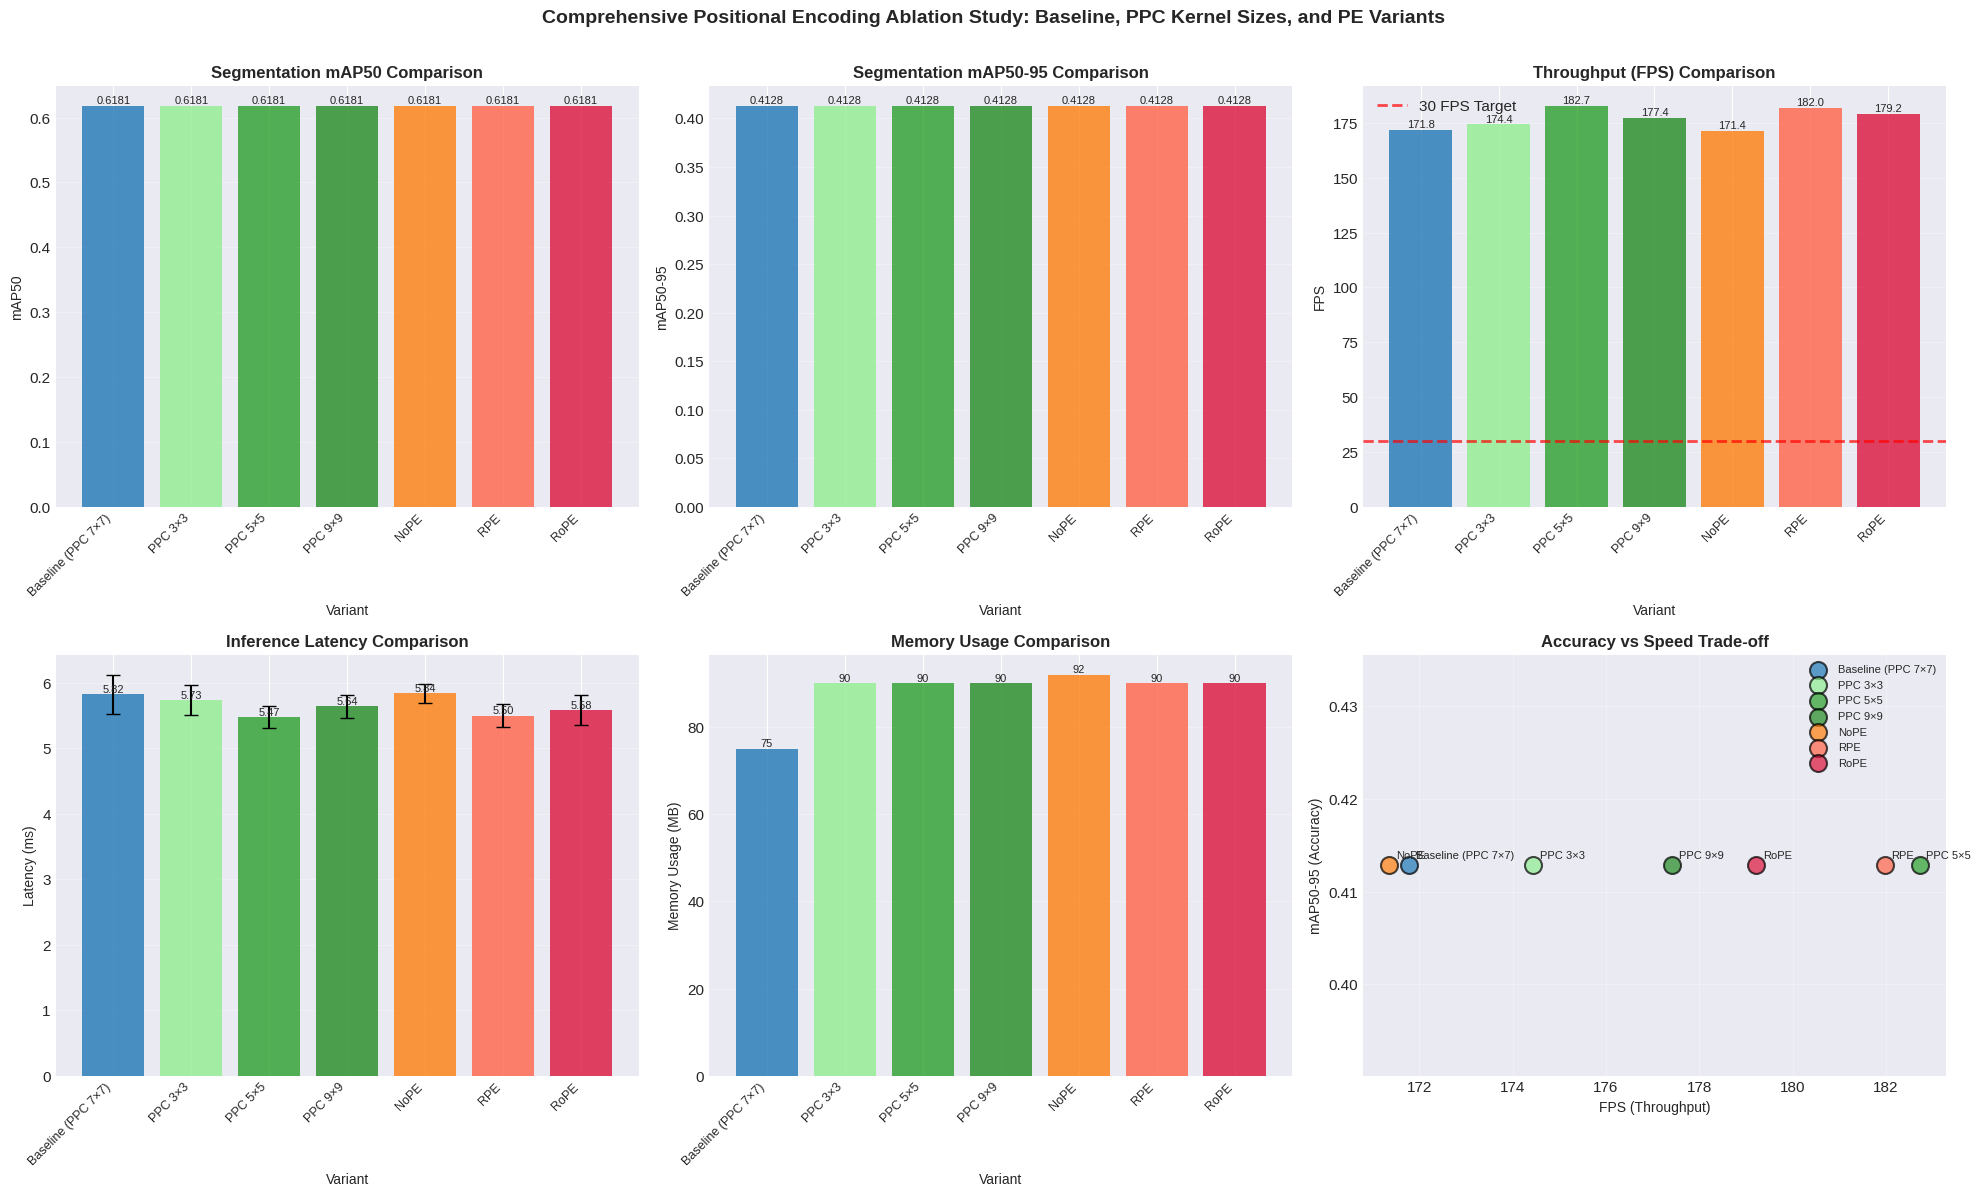


Total variants visualized: 7
Variants: Baseline (PPC 7×7), PPC 3×3, PPC 5×5, PPC 9×9, NoPE, RPE, RoPE


In [ ]:
# Comprehensive Visualization: All Variants Together
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ensure results DataFrame exists
if 'results' not in locals() or len(results) == 0:
    print("No results available. Please run Cell 11 (Comprehensive Experiment Loop) first.")
else:
    # Convert results to DataFrame
    df = pd.DataFrame(results)
    
    # Filter GPU results
    gpu_results = df[df['device'] == 'cuda'].copy() if cuda_available and 'device' in df.columns and len(df) > 0 else df.copy()
    
    if len(gpu_results) == 0:
        print("No GPU results available for visualization.")
    else:
        # Create a unified variant label column if it doesn't exist
        if 'variant_label' not in gpu_results.columns:
            # Create variant_label from available columns
            if 'ppc_kernel_size' in gpu_results.columns:
                gpu_results['variant_label'] = gpu_results.apply(
                    lambda row: f"PPC {row['ppc_kernel_size']}×{row['ppc_kernel_size']}" 
                    if pd.notna(row['ppc_kernel_size']) else 'Baseline', axis=1
                )
            elif 'variant_type' in gpu_results.columns and 'variant_value' in gpu_results.columns:
                # Use existing variant_label if available
                gpu_results['variant_label'] = gpu_results.apply(
                    lambda row: row.get('variant_label', 
                        f"{row['variant_type']}_{row['variant_value']}" if pd.notna(row.get('variant_type')) else 'Unknown'),
                    axis=1
                )
            else:
                gpu_results['variant_label'] = 'Unknown'
        
        # Sort variants in a logical order: Baseline, PPC variants (3,5,7,9), PE variants (NoPE, RPE, RoPE)
        variant_order = ['Baseline (PPC 7×7)', 'PPC 3×3', 'PPC 5×5', 'PPC 7×7', 'PPC 9×9', 'NoPE', 'RPE', 'RoPE']
        variants_list = []
        for vo in variant_order:
            if vo in gpu_results['variant_label'].values:
                variants_list.append(vo)
        # Add any remaining variants not in the order list
        for v in sorted(gpu_results['variant_label'].unique()):
            if v not in variants_list:
                variants_list.append(v)
        
        # Create comprehensive figure with 6 subplots
        fig = plt.figure(figsize=(20, 12))
        
        # Color scheme: Baseline=blue, PPC=green shades, PE=orange/red shades
        colors = {}
        for v in variants_list:
            if 'Baseline' in v:
                colors[v] = '#1f77b4'  # Blue
            elif 'PPC' in v:
                if '3×3' in v:
                    colors[v] = '#90ee90'  # Light Green
                elif '5×5' in v:
                    colors[v] = '#2ca02c'  # Green
                elif '7×7' in v:
                    colors[v] = '#32cd32'  # Lime green
                elif '9×9' in v:
                    colors[v] = '#228b22'  # Forest green
                else:
                    colors[v] = '#2ca02c'
            elif v == 'NoPE':
                colors[v] = '#ff7f0e'  # Orange
            elif v == 'RPE':
                colors[v] = '#ff6347'  # Tomato
            elif v == 'RoPE':
                colors[v] = '#dc143c'  # Crimson
            else:
                colors[v] = '#808080'  # Gray
        
        # 1. Combined mAP50 and mAP50-95 Comparison
        ax1 = plt.subplot(2, 3, 1)
        if 'map50' in gpu_results.columns and gpu_results['map50'].notna().any():
            map50_values = []
            map50_95_values = []
            for v in variants_list:
                v_data = gpu_results[gpu_results['variant_label'] == v]
                if len(v_data) > 0:
                    map50_val = v_data.iloc[0]['map50'] if v_data['map50'].notna().any() else 0.0
                    map50_95_val = v_data.iloc[0]['map50_95'] if 'map50_95' in v_data.columns and v_data['map50_95'].notna().any() and v_data.iloc[0]['map50_95'] > 0 else 0.0
                    map50_values.append(map50_val)
                    map50_95_values.append(map50_95_val)
                else:
                    map50_values.append(0)
                    map50_95_values.append(0)
            
            # Create grouped bar chart
            x = np.arange(len(variants_list))
            width = 0.35
            
            bars1 = ax1.bar(x - width/2, map50_values, width, label='mAP50', 
                           color=[colors.get(v, '#808080') for v in variants_list], alpha=0.8)
            bars2 = ax1.bar(x + width/2, map50_95_values, width, label='mAP50-95',
                           color=[colors.get(v, '#808080') for v in variants_list], alpha=0.6, hatch='//')
            
            ax1.set_xlabel('Variant', fontsize=10)
            ax1.set_ylabel('mAP Score', fontsize=10)
            ax1.set_title('Segmentation Accuracy Comparison (mAP50 & mAP50-95)', fontsize=12, fontweight='bold')
            ax1.set_xticks(x)
            ax1.set_xticklabels(variants_list, rotation=45, ha='right', fontsize=9)
            ax1.legend(fontsize=9)
            ax1.grid(True, alpha=0.3, axis='y')
            
            # Add value labels on bars
            for bars, values in [(bars1, map50_values), (bars2, map50_95_values)]:
                for bar, val in zip(bars, values):
                    if val > 0:
                        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                                f'{val:.4f}', ha='center', va='bottom', fontsize=7)
        else:
            ax1.text(0.5, 0.5, 'mAP data not available', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_title('Segmentation Accuracy Comparison', fontsize=12, fontweight='bold')
        
        # 2. FPS Comparison
        ax2 = plt.subplot(2, 3, 2)
        if 'fps' in gpu_results.columns:
            fps_values = []
            for v in variants_list:
                v_data = gpu_results[gpu_results['variant_label'] == v]
                fps_values.append(v_data.iloc[0]['fps'] if len(v_data) > 0 else 0)
            
            bars = ax2.bar(range(len(variants_list)), fps_values, color=[colors.get(v, '#808080') for v in variants_list], alpha=0.8)
            ax2.axhline(y=30, color='r', linestyle='--', linewidth=2, label='30 FPS Target', alpha=0.7)
            ax2.set_xlabel('Variant', fontsize=10)
            ax2.set_ylabel('FPS', fontsize=10)
            ax2.set_title('Throughput (FPS) Comparison', fontsize=12, fontweight='bold')
            ax2.set_xticks(range(len(variants_list)))
            ax2.set_xticklabels(variants_list, rotation=45, ha='right', fontsize=9)
            ax2.legend()
            ax2.grid(True, alpha=0.3, axis='y')
            
            for bar, val in zip(bars, fps_values):
                if val > 0:
                    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                            f'{val:.1f}', ha='center', va='bottom', fontsize=8)
        else:
            ax2.text(0.5, 0.5, 'FPS data not available', ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('Throughput (FPS) Comparison', fontsize=12, fontweight='bold')
        
        # 3. Latency Comparison
        ax3 = plt.subplot(2, 3, 3)
        if 'avg_latency_ms' in gpu_results.columns:
            latency_values = []
            std_values = []
            for v in variants_list:
                v_data = gpu_results[gpu_results['variant_label'] == v]
                if len(v_data) > 0:
                    latency_values.append(v_data.iloc[0]['avg_latency_ms'])
                    std_values.append(v_data.iloc[0].get('std_latency_ms', 0))
                else:
                    latency_values.append(0)
                    std_values.append(0)
            
            bars = ax3.bar(range(len(variants_list)), latency_values, 
                          yerr=std_values if any(std_values) else None,
                          color=[colors.get(v, '#808080') for v in variants_list], 
                          alpha=0.8, capsize=5)
            ax3.set_xlabel('Variant', fontsize=10)
            ax3.set_ylabel('Latency (ms)', fontsize=10)
            ax3.set_title('Inference Latency Comparison', fontsize=12, fontweight='bold')
            ax3.set_xticks(range(len(variants_list)))
            ax3.set_xticklabels(variants_list, rotation=45, ha='right', fontsize=9)
            ax3.grid(True, alpha=0.3, axis='y')
            
            for bar, val in zip(bars, latency_values):
                if val > 0:
                    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                            f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        else:
            ax3.text(0.5, 0.5, 'Latency data not available', ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Inference Latency Comparison', fontsize=12, fontweight='bold')
        
        # 4. Memory Usage Comparison
        ax4 = plt.subplot(2, 3, 4)
        if 'max_memory_mb' in gpu_results.columns:
            memory_values = []
            for v in variants_list:
                v_data = gpu_results[gpu_results['variant_label'] == v]
                memory_values.append(v_data.iloc[0]['max_memory_mb'] if len(v_data) > 0 else 0)
            
            bars = ax4.bar(range(len(variants_list)), memory_values, color=[colors.get(v, '#808080') for v in variants_list], alpha=0.8)
            ax4.set_xlabel('Variant', fontsize=10)
            ax4.set_ylabel('Memory Usage (MB)', fontsize=10)
            ax4.set_title('Memory Usage Comparison', fontsize=12, fontweight='bold')
            ax4.set_xticks(range(len(variants_list)))
            ax4.set_xticklabels(variants_list, rotation=45, ha='right', fontsize=9)
            ax4.grid(True, alpha=0.3, axis='y')
            
            for bar, val in zip(bars, memory_values):
                if val > 0:
                    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                            f'{val:.0f}', ha='center', va='bottom', fontsize=8)
        else:
            ax4.text(0.5, 0.5, 'Memory data not available', ha='center', va='center', transform=ax4.transAxes)
            ax4.set_title('Memory Usage Comparison', fontsize=12, fontweight='bold')
        
        # 5. Trade-off Plot: mAP50 vs FPS
        ax5 = plt.subplot(2, 3, 5)
        if 'map50' in gpu_results.columns and 'fps' in gpu_results.columns:
            for v in variants_list:
                v_data = gpu_results[gpu_results['variant_label'] == v]
                if len(v_data) > 0:
                    map50_val = v_data.iloc[0]['map50'] if v_data['map50'].notna().any() else None
                    fps_val = v_data.iloc[0]['fps']
                    
                    if map50_val is not None and not np.isnan(map50_val) and not np.isnan(fps_val):
                        ax5.scatter(fps_val, map50_val, 
                                  label=v,
                                  alpha=0.7, s=150,
                                  color=colors.get(v, '#808080'),
                                  edgecolors='black', linewidths=1.5, marker='o')
                        
                        # Add label
                        ax5.annotate(v, (fps_val, map50_val),
                                   xytext=(5, 5), textcoords='offset points', fontsize=8)
            
            ax5.set_xlabel('FPS (Throughput)', fontsize=10)
            ax5.set_ylabel('mAP50 (Accuracy)', fontsize=10)
            ax5.set_title('mAP50 vs Speed Trade-off', fontsize=12, fontweight='bold')
            ax5.legend(fontsize=8, loc='best')
            ax5.grid(True, alpha=0.3)
        else:
            ax5.text(0.5, 0.5, 'Trade-off data not available', ha='center', va='center', transform=ax5.transAxes)
            ax5.set_title('mAP50 vs Speed Trade-off', fontsize=12, fontweight='bold')
        
        # 6. Trade-off Plot: mAP50-95 vs FPS (if available)
        ax6 = plt.subplot(2, 3, 6)
        if 'map50_95' in gpu_results.columns and 'fps' in gpu_results.columns:
            has_map50_95_data = False
            for v in variants_list:
                v_data = gpu_results[gpu_results['variant_label'] == v]
                if len(v_data) > 0 and v_data['map50_95'].notna().any():
                    map_val = v_data.iloc[0]['map50_95']
                    fps_val = v_data.iloc[0]['fps']
                    
                    if not np.isnan(map_val) and map_val > 0 and not np.isnan(fps_val):
                        has_map50_95_data = True
                        ax6.scatter(fps_val, map_val, 
                                  label=v,
                                  alpha=0.7, s=150,
                                  color=colors.get(v, '#808080'),
                                  edgecolors='black', linewidths=1.5, marker='s')
                        
                        # Add label
                        ax6.annotate(v, (fps_val, map_val),
                                   xytext=(5, 5), textcoords='offset points', fontsize=8)
            
            if has_map50_95_data:
                ax6.set_xlabel('FPS (Throughput)', fontsize=10)
                ax6.set_ylabel('mAP50-95 (Accuracy)', fontsize=10)
                ax6.set_title('mAP50-95 vs Speed Trade-off', fontsize=12, fontweight='bold')
                ax6.legend(fontsize=8, loc='best')
                ax6.grid(True, alpha=0.3)
            else:
                ax6.text(0.5, 0.5, 'mAP50-95 data not available\n(All values are 0)', ha='center', va='center', transform=ax6.transAxes, fontsize=10)
                ax6.set_title('mAP50-95 vs Speed Trade-off', fontsize=12, fontweight='bold')
        else:
            ax6.text(0.5, 0.5, 'mAP50-95 data not available', ha='center', va='center', transform=ax6.transAxes)
            ax6.set_title('mAP50-95 vs Speed Trade-off', fontsize=12, fontweight='bold')
        
        plt.suptitle('Comprehensive Positional Encoding Ablation Study: Baseline, PPC Kernel Sizes, and PE Variants', 
                     fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.99])
        
        # Save figure
        output_dir = Path('/home/tiehangz/proj/yolov12/modification/outputs')
        output_dir.mkdir(exist_ok=True, parents=True)
        output_path = output_dir / 'comprehensive_pe_ablation_comparison.png'
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"\nVisualization saved to: {output_path}")
        plt.show()
        
        print(f"\nTotal variants visualized: {len(variants_list)}")
        print(f"Variants: {', '.join(variants_list)}")


## Save Results

Save results to CSV file for further analysis.


In [18]:
# Save results to CSV
output_dir = Path('/home/tiehangz/proj/yolov12/modification/outputs')
output_dir.mkdir(exist_ok=True, parents=True)

# Prepare DataFrame for saving (exclude list columns)
df_save = df.copy()
if 'latencies' in df_save.columns:
    df_save = df_save.drop(columns=['latencies'])
if 'memory_samples' in df_save.columns:
    df_save = df_save.drop(columns=['memory_samples'])

csv_path = output_dir / 'comprehensive_comprehensive_pe_ablation_results.csv'
df_save.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}")

# Display final summary table
print("\n" + "=" * 80)
print("Final Summary Table")
print("=" * 80)
print(df_save.to_string(index=False))


Results saved to /home/tiehangz/proj/yolov12/modification/outputs/comprehensive_comprehensive_pe_ablation_results.csv

Final Summary Table
       model variant_type variant_value      variant_label device                                        model_path  avg_latency_ms  std_latency_ms        fps  avg_memory_mb  max_memory_mb    map50  map50_95
yolov12n-seg     baseline       ppc_7x7 Baseline (PPC 7×7)   cuda /home/tiehangz/proj/yolov12/model/yolov12n-seg.pt        5.821447        0.296714 171.778611      74.933594      74.933594 0.618059  0.412843
yolov12n-seg          ppc       ppc_3x3            PPC 3×3   cuda /home/tiehangz/proj/yolov12/model/yolov12n-seg.pt        5.732653        0.231602 174.439296      89.876465      89.876465 0.618059  0.412843
yolov12n-seg          ppc       ppc_5x5            PPC 5×5   cuda /home/tiehangz/proj/yolov12/model/yolov12n-seg.pt        5.472946        0.170083 182.716935      89.876465      89.876465 0.618059  0.412843
yolov12n-seg          ppc    